In [41]:
import config
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
FINDEX_PROCESSED_CSV_PATH = "../data/processed/pakistan_digital_payments_findex.csv"

TRENDS_CATEGORIES = {
    'primary_wallets': '../data/processed/trends_primary_wallets.csv',
    'payment_features': '../data/processed/trends_payment_features.csv',
    'use_cases': '../data/processed/trends_use_cases.csv',
    'banking_terms': '../data/processed/trends_banking_terms.csv'
}

### Require:
- At least one time-series plot showing trends over time (search trends)
- At least one barchart or histogram for categorical / frequency data (pick some indicators in findex)
- At least one visualisation exploring variable correlations (search trends)

In [43]:
findex_data = pd.read_csv(FINDEX_PROCESSED_CSV_PATH)

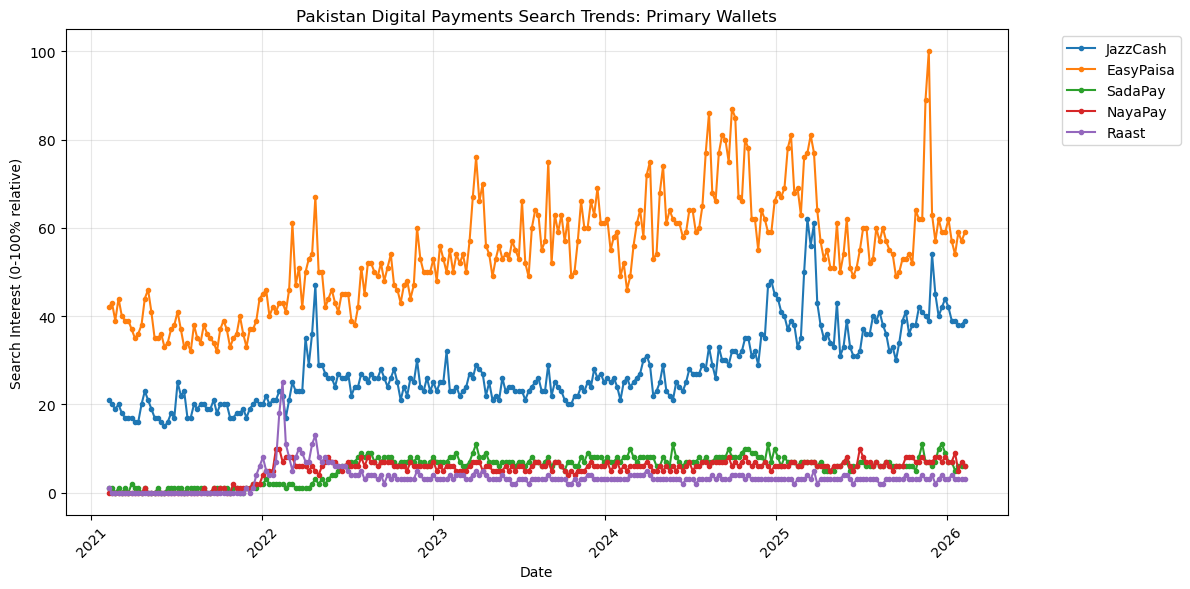

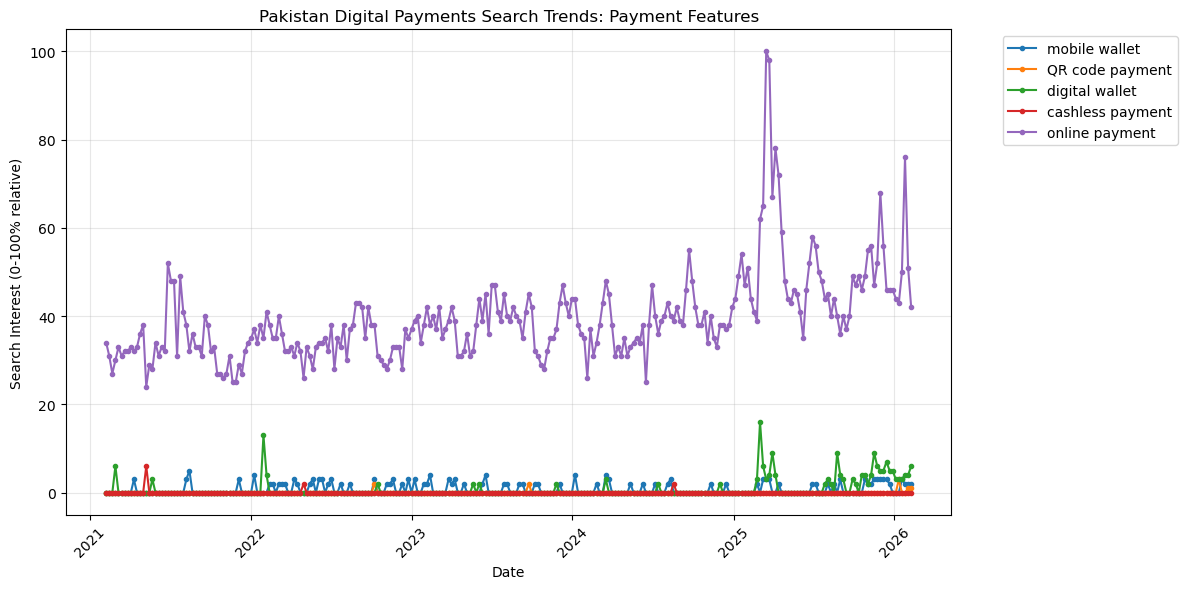

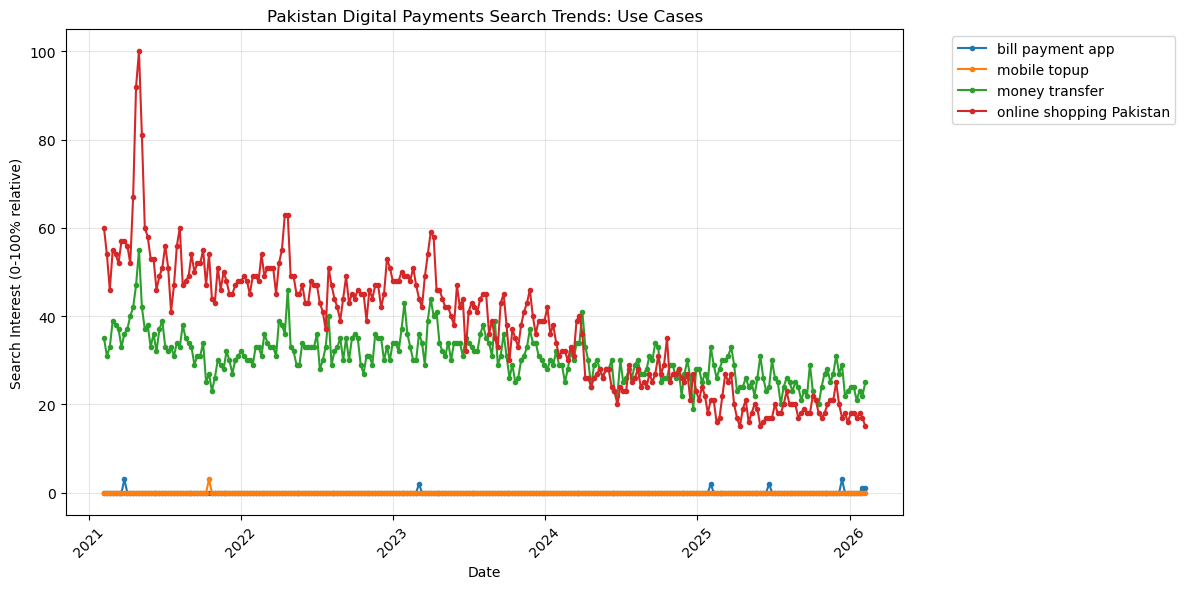

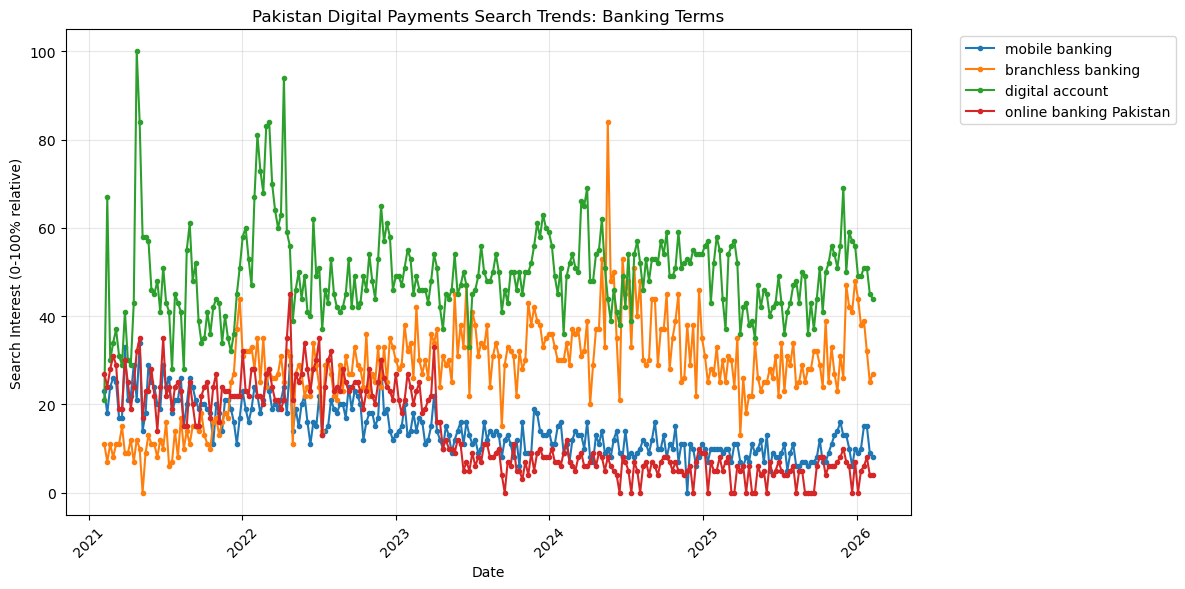

In [44]:
# time-series plots for search trends data
# plot time series for each category
for category_name, filepath in TRENDS_CATEGORIES.items():
    
    df = pd.read_csv(filepath)
    
    # drop unnamed col artifact...
    df = df.drop("Unnamed: 0", axis=1)
    
    df['date'] = pd.to_datetime(df['date'])
    
    plt.figure(figsize=(12, 6))
    
    # get keyword columns (all except date)
    keyword_cols = [col for col in df.columns if col != 'date']
    
    for keyword in keyword_cols:
        plt.plot(df['date'], df[keyword], label=keyword, marker='o', markersize=3)
    
    plt.xlabel('Date')
    plt.ylabel('Search Interest (0-100% relative)')
    plt.title(f'Pakistan Digital Payments Search Trends: {category_name.replace("_", " ").title()}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##### Selecting the `banking_terms` category for correlation analysis...

In [45]:
banking_terms_df = pd.read_csv(TRENDS_CATEGORIES['banking_terms'])

In [46]:
banking_terms_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               262 non-null    int64 
 1   date                     262 non-null    object
 2   mobile banking           262 non-null    int64 
 3   branchless banking       262 non-null    int64 
 4   digital account          262 non-null    int64 
 5   online banking Pakistan  262 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 12.4+ KB


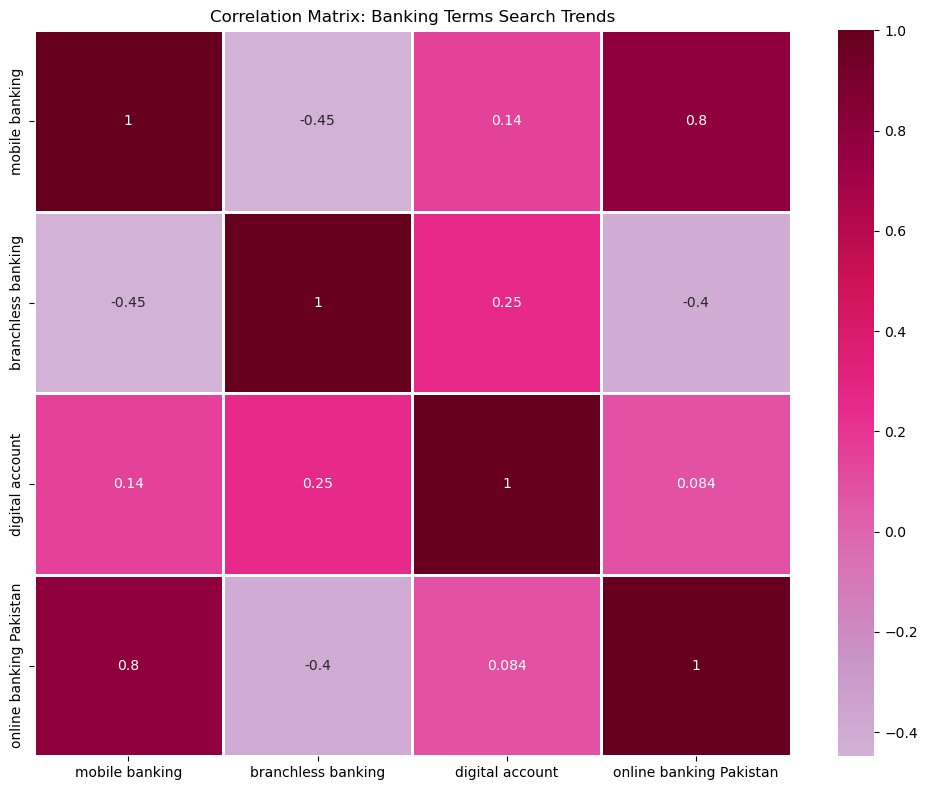

In [47]:
# correlation analysis on keywords related to banking...

correlation_matrix = banking_terms_df[keyword_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='PuRd', center=0, linewidths=1)
plt.title('Correlation Matrix: Banking Terms Search Trends')
plt.tight_layout()
plt.show()


In [48]:
findex_data.INDICATOR_LABEL.unique()

array(['Used a mobile phone or the internet to pay bills',
       'Used a mobile phone or the internet to buy something online',
       'Made or received a digital payment',
       'Made a digital merchant payment', 'Mobile money account',
       'Digitally enabled account',
       'Used mobile phone or card to pay for in-store purchase',
       'Made a utility payment: using a mobile phone',
       'Received digital payments',
       'Received wages: through a mobile phone'], dtype=object)

In [49]:
findex_data.AGE_LABEL.unique()

array(['15 years old and over', '25 years old and over',
       '15 to 24 years old'], dtype=object)

In [50]:
# lets show data from 2024, for the total population (15-24 years old)
findex_data_filtered = findex_data[(findex_data['TIME_PERIOD'] == 2024) & (findex_data['SEX_LABEL'] == 'Total') & ((findex_data['AGE_LABEL'] == "15 to 24 years old") | (findex_data['AGE_LABEL'] == "25 years old and over"))]

In [51]:
findex_data_filtered

,Unnamed: 0,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE,REF_AREA_LABEL,SEX_LABEL,AGE_LABEL,URBANISATION_LABEL,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL
7,80244,2024,Made or received a digital payment,25.061713,Pakistan,Total,25 years old and over,Total,Total,Total,Total
8,80245,2024,Made or received a digital payment,23.647004,Pakistan,Total,15 to 24 years old,Total,Total,Total,Total
39,87090,2024,Mobile money account,18.270397,Pakistan,Total,25 years old and over,Total,Total,Total,Total
40,87091,2024,Mobile money account,18.565077,Pakistan,Total,15 to 24 years old,Total,Total,Total,Total
52,94786,2024,Digitally enabled account,20.154408,Pakistan,Total,25 years old and over,Total,Total,Total,Total
53,94787,2024,Digitally enabled account,19.123352,Pakistan,Total,15 to 24 years old,Total,Total,Total,Total
74,294379,2024,Received digital payments,18.563978,Pakistan,Total,25 years old and over,Total,Total,Total,Total
75,294380,2024,Received digital payments,14.421769,Pakistan,Total,15 to 24 years old,Total,Total,Total,Total


In [52]:
data_15_to_24_yo = findex_data_filtered[(findex_data_filtered['AGE_LABEL'] == "15 to 24 years old")]
data_25_and_up = findex_data_filtered[(findex_data_filtered['AGE_LABEL'] == '25 years old and over')]

In [53]:
data_15_to_24_yo.AGE_LABEL.unique()

array(['15 to 24 years old'], dtype=object)

In [54]:
data_25_and_up.AGE_LABEL.unique()

array(['25 years old and over'], dtype=object)

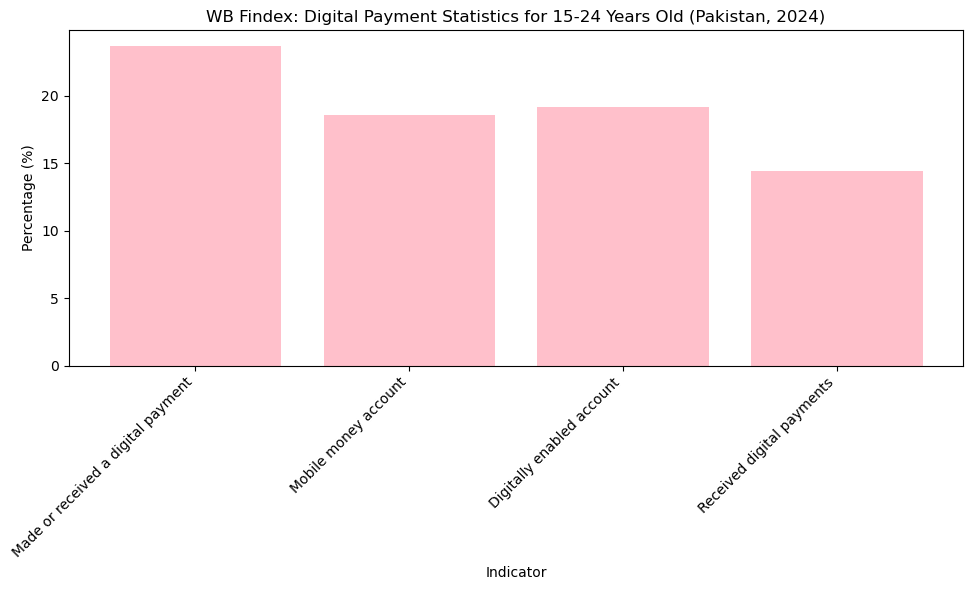

In [55]:
# plot data for 15-24 y/o

plt.figure(figsize=(10, 6))
plt.bar(data_15_to_24_yo['INDICATOR_LABEL'], data_15_to_24_yo['OBS_VALUE'], color='pink')
plt.xlabel('Indicator')
plt.ylabel('Percentage (%)')
plt.title('WB Findex: Digital Payment Statistics for 15-24 Years Old (Pakistan, 2024)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

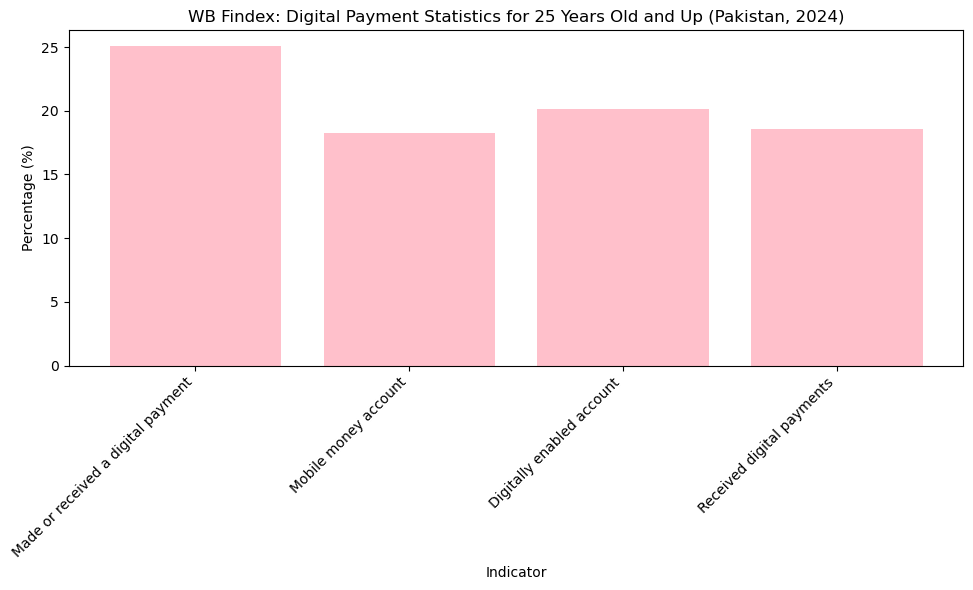

In [56]:
# plot data for 25 y/o and up

plt.figure(figsize=(10, 6))
plt.bar(data_25_and_up['INDICATOR_LABEL'], data_25_and_up['OBS_VALUE'], color="pink")
plt.xlabel('Indicator')
plt.ylabel('Percentage (%)')
plt.title('WB Findex: Digital Payment Statistics for 25 Years Old and Up (Pakistan, 2024)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()